# 🔌 Notebook 1: Sensor Data Simulation & MQTT Basics
**DigiHaz Doctoral Training Programme — Module 7: AI-Assisted IoT Development**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Digihaz/digihaz-course-materials/blob/dev/module_07_iot_sensor_networks/topic_04/notebooks/01_sensor_simulation_mqtt.ipynb)

---

This notebook lets you **simulate the three workshop sensors** entirely in Python — no hardware required. You will:

1. Simulate realistic MPU6050 (tilt), BMP280 (pressure), and soil moisture readings
2. Format them as JSON messages, the same way a real ESP32 would
3. Publish them to a **public MQTT broker** that anyone can subscribe to
4. Implement local threshold logic for a landslide alert

By the end you will understand the **data flow** before touching any hardware.

---

In [7]:
# paho-mqtt is the only library we need that is not on Colab by default
!pip install paho-mqtt --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import time
from datetime import datetime, timezone
import paho.mqtt.client as mqtt
import warnings
warnings.filterwarnings('ignore')

PURPLE='#3D3780'; RED='#E63946'; ORANGE='#E07B24'
GREEN='#16A34A';  BLUE='#0A6EBD'; DARK='#1C1C2E'

print('✅ Libraries loaded')

✅ Libraries loaded


---
## Part 1 — Simulating the MPU6050 (Tilt Sensor)

The MPU6050 is a 6-axis inertial measurement unit. For landslide monitoring we care about **tilt angle** — how far the sensor has rotated from vertical.

We compute tilt from the accelerometer readings using:

$$\theta = \arctan\left(\frac{\sqrt{a_x^2 + a_y^2}}{a_z}\right)$$

Run this cell to simulate a **slope that slowly tilts over time** — typical of pre-failure landslide creep:

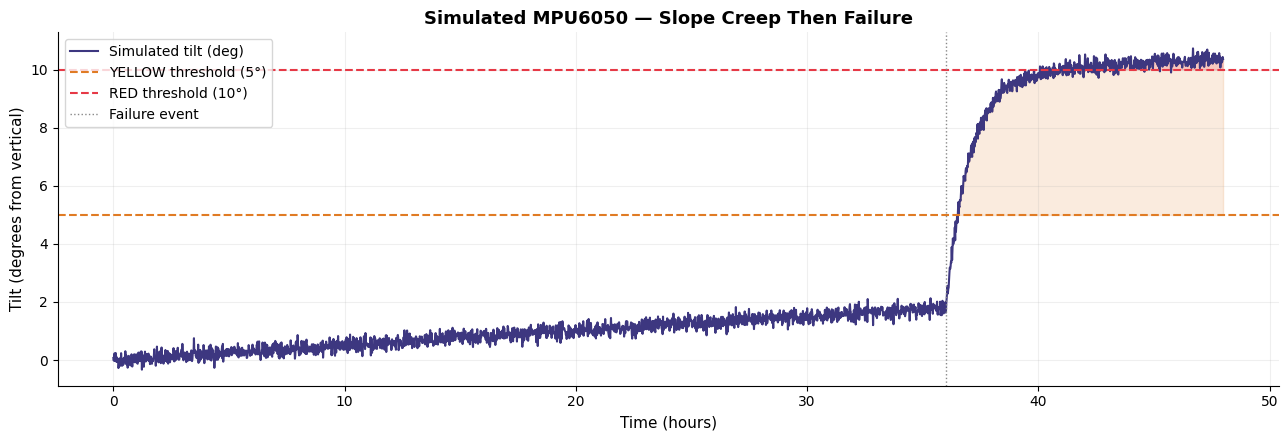

Generated 2880 samples over 48 hours
Max tilt: 10.74°  |  Final tilt: 10.37°


In [8]:
# ── PARAMETERS ───────────────────────────────────────────────────────
DURATION_HOURS = 48        # simulation length
SAMPLE_RATE_S  = 60        # one reading per minute
FAILURE_AT_HOUR = 36       # when the slope finally fails
# ─────────────────────────────────────────────────────────────────────

np.random.seed(42)
n_samples = int(DURATION_HOURS * 3600 / SAMPLE_RATE_S)
t_hours = np.arange(n_samples) * SAMPLE_RATE_S / 3600

# Slow creep before failure, then a sudden lurch
creep    = 0.05 * t_hours
failure  = np.where(t_hours > FAILURE_AT_HOUR,
                    8 * (1 - np.exp(-(t_hours - FAILURE_AT_HOUR))), 0)
noise    = np.random.normal(0, 0.15, n_samples)
tilt_deg = creep + failure + noise

# Plot it
fig, ax = plt.subplots(figsize=(13, 4.5), facecolor='white')
ax.plot(t_hours, tilt_deg, color=PURPLE, lw=1.5, label='Simulated tilt (deg)')
ax.axhline(5, color=ORANGE, lw=1.5, ls='--', label='YELLOW threshold (5°)')
ax.axhline(10, color=RED, lw=1.5, ls='--', label='RED threshold (10°)')
ax.axvline(FAILURE_AT_HOUR, color='#888', lw=1, ls=':', label='Failure event')
ax.fill_between(t_hours, 5, tilt_deg, where=tilt_deg>5, color=ORANGE, alpha=0.15)
ax.fill_between(t_hours, 10, tilt_deg, where=tilt_deg>10, color=RED, alpha=0.2)

ax.set_xlabel('Time (hours)', fontsize=11)
ax.set_ylabel('Tilt (degrees from vertical)', fontsize=11)
ax.set_title('Simulated MPU6050 — Slope Creep Then Failure', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Generated {n_samples} samples over {DURATION_HOURS} hours')
print(f'Max tilt: {tilt_deg.max():.2f}°  |  Final tilt: {tilt_deg[-1]:.2f}°')

---
## Part 2 — Simulating the BMP280 (Pressure & Temperature)

Pressure drops sharply before storms — this is one of the oldest weather forecasting principles. We will simulate atmospheric pressure with diurnal variation and a storm event:

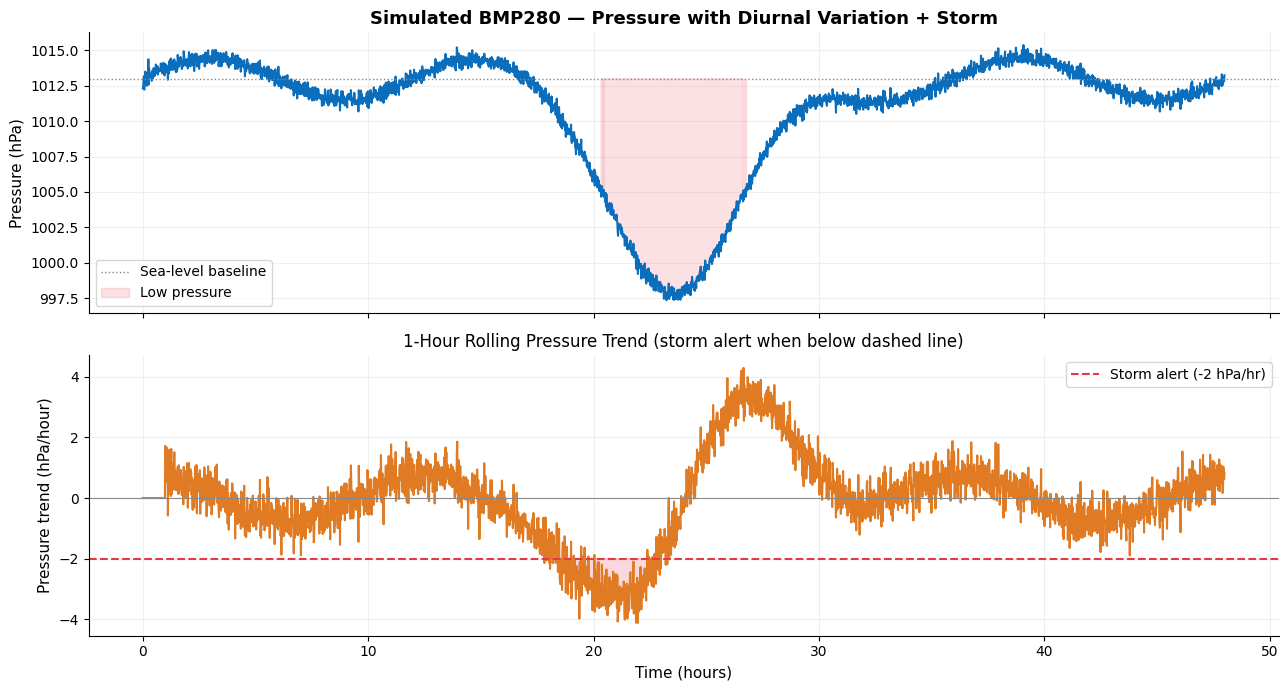

Min pressure: 997.3 hPa | Min trend: -4.13 hPa/hr


In [9]:
# Baseline pressure ~ 1013 hPa with diurnal sine wave
pressure_hpa = 1013 + 1.5 * np.sin(2 * np.pi * t_hours / 12)

# Storm: pressure drops 15 hPa over 6 hours, recovers over next 6
storm_centre = 24  # storm peaks at hour 24
storm = -15 * np.exp(-((t_hours - storm_centre) / 4)**2)
pressure_hpa += storm

# Random noise
pressure_hpa += np.random.normal(0, 0.3, n_samples)

# Temperature: diurnal variation 18–28 °C
temperature_c = 23 + 5 * np.sin(2 * np.pi * (t_hours - 6) / 24) + np.random.normal(0, 0.4, n_samples)

# Compute 1-hour rolling pressure trend (hPa/hour)
window = 60  # 60 samples = 1 hour
pressure_trend = pd.Series(pressure_hpa).diff(window).fillna(0).values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), facecolor='white', sharex=True)

ax1.plot(t_hours, pressure_hpa, color=BLUE, lw=1.5)
ax1.axhline(1013, color='#888', lw=1, ls=':', label='Sea-level baseline')
ax1.fill_between(t_hours, pressure_hpa, 1013, where=pressure_hpa<1005,
                  color=RED, alpha=0.15, label='Low pressure')
ax1.set_ylabel('Pressure (hPa)', fontsize=11)
ax1.set_title('Simulated BMP280 — Pressure with Diurnal Variation + Storm', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.2)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2.plot(t_hours, pressure_trend, color=ORANGE, lw=1.5)
ax2.axhline(-2, color=RED, lw=1.5, ls='--', label='Storm alert (-2 hPa/hr)')
ax2.axhline(0, color='#888', lw=0.8)
ax2.fill_between(t_hours, pressure_trend, -2, where=pressure_trend<-2,
                  color=RED, alpha=0.2)
ax2.set_xlabel('Time (hours)', fontsize=11)
ax2.set_ylabel('Pressure trend (hPa/hour)', fontsize=11)
ax2.set_title('1-Hour Rolling Pressure Trend (storm alert when below dashed line)', fontsize=12)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.2)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Min pressure: {pressure_hpa.min():.1f} hPa | Min trend: {pressure_trend.min():.2f} hPa/hr')

---
## Part 3 — Simulating the Soil Moisture Sensor

The capacitive soil moisture sensor outputs an **analogue voltage** (read by an ADC) that depends on water content. We calibrate it linearly between dry and wet endpoints.

We simulate a soil that **gradually saturates** as the storm passes, then slowly drains:

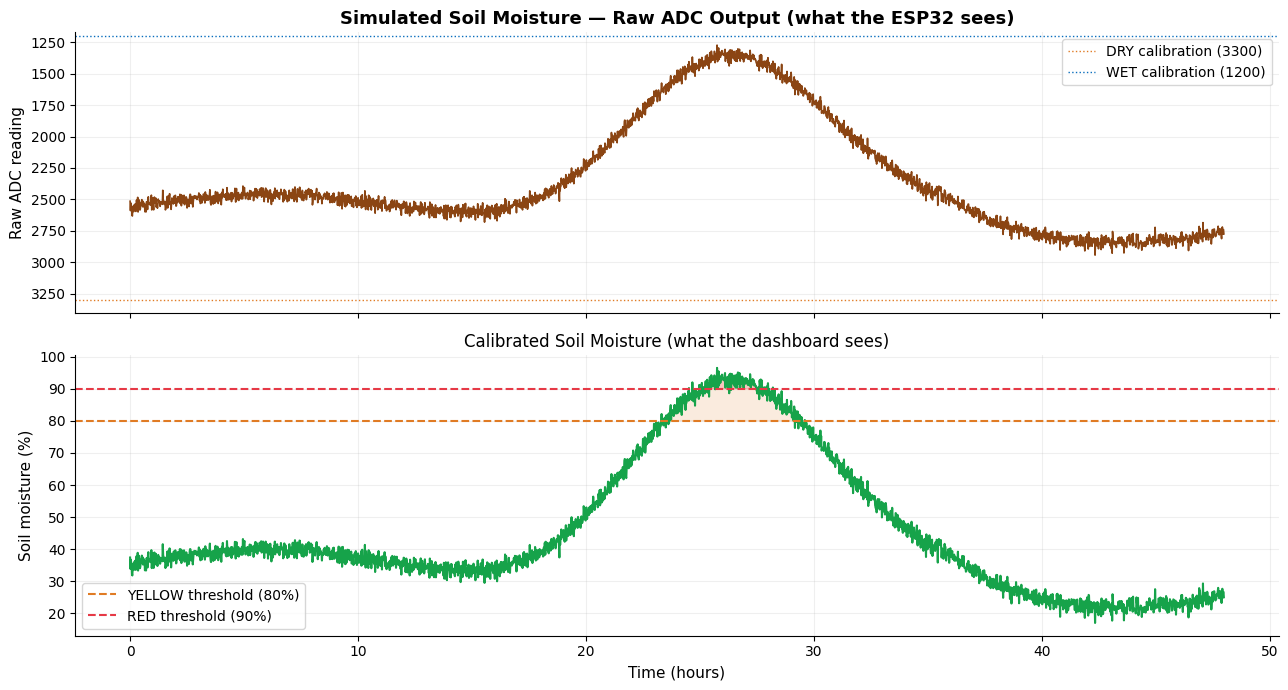

Max soil moisture: 96.5% at hour 25.8


In [10]:
# Calibration constants for a typical capacitive sensor
ADC_DRY = 3300   # raw ADC reading in completely dry soil
ADC_WET = 1200   # raw ADC reading in saturated soil

# Soil moisture profile: stays low, saturates during the storm, drains slowly
base_moisture = 35 + 5 * np.sin(2 * np.pi * t_hours / 24)
storm_saturation = 55 * np.exp(-((t_hours - 26) / 6)**2)
drain_after_failure = -10 * np.where(t_hours > FAILURE_AT_HOUR,
                                      1 - np.exp(-(t_hours - FAILURE_AT_HOUR) / 4), 0)
soil_pct = base_moisture + storm_saturation + drain_after_failure + np.random.normal(0, 1.5, n_samples)
soil_pct = np.clip(soil_pct, 0, 100)

# Convert percentage back to raw ADC reading (as the real sensor would output)
soil_raw = ADC_DRY - (soil_pct / 100) * (ADC_DRY - ADC_WET)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), facecolor='white', sharex=True)

ax1.plot(t_hours, soil_raw, color='#8B4513', lw=1.2)
ax1.axhline(ADC_DRY, color=ORANGE, ls=':', lw=1, label=f'DRY calibration ({ADC_DRY})')
ax1.axhline(ADC_WET, color=BLUE, ls=':', lw=1, label=f'WET calibration ({ADC_WET})')
ax1.set_ylabel('Raw ADC reading', fontsize=11)
ax1.set_title('Simulated Soil Moisture — Raw ADC Output (what the ESP32 sees)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.2)
ax1.invert_yaxis()  # higher ADC = drier, so invert for intuition
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2.plot(t_hours, soil_pct, color=GREEN, lw=1.5)
ax2.axhline(80, color=ORANGE, lw=1.5, ls='--', label='YELLOW threshold (80%)')
ax2.axhline(90, color=RED, lw=1.5, ls='--', label='RED threshold (90%)')
ax2.fill_between(t_hours, 80, soil_pct, where=soil_pct>80, color=ORANGE, alpha=0.15)
ax2.fill_between(t_hours, 90, soil_pct, where=soil_pct>90, color=RED, alpha=0.2)
ax2.set_xlabel('Time (hours)', fontsize=11)
ax2.set_ylabel('Soil moisture (%)', fontsize=11)
ax2.set_title('Calibrated Soil Moisture (what the dashboard sees)', fontsize=12)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.2)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Max soil moisture: {soil_pct.max():.1f}% at hour {t_hours[np.argmax(soil_pct)]:.1f}')

---
## Part 4 — Combining All Three Sensors

The **landslide pre-failure heuristic** combines tilt and soil moisture:

- Tilt > 5° **AND** soil > 80%  →  **YELLOW** alert
- Tilt > 10° **AND** soil > 90%  →  **RED** alert

Pressure trend gives an **earlier** warning — the storm precedes the soil saturation by hours.

YELLOW alert never triggered
RED alert never triggered

First STORM alert at hour 17.8
(precedes first landslide alert by hours — useful lead time)


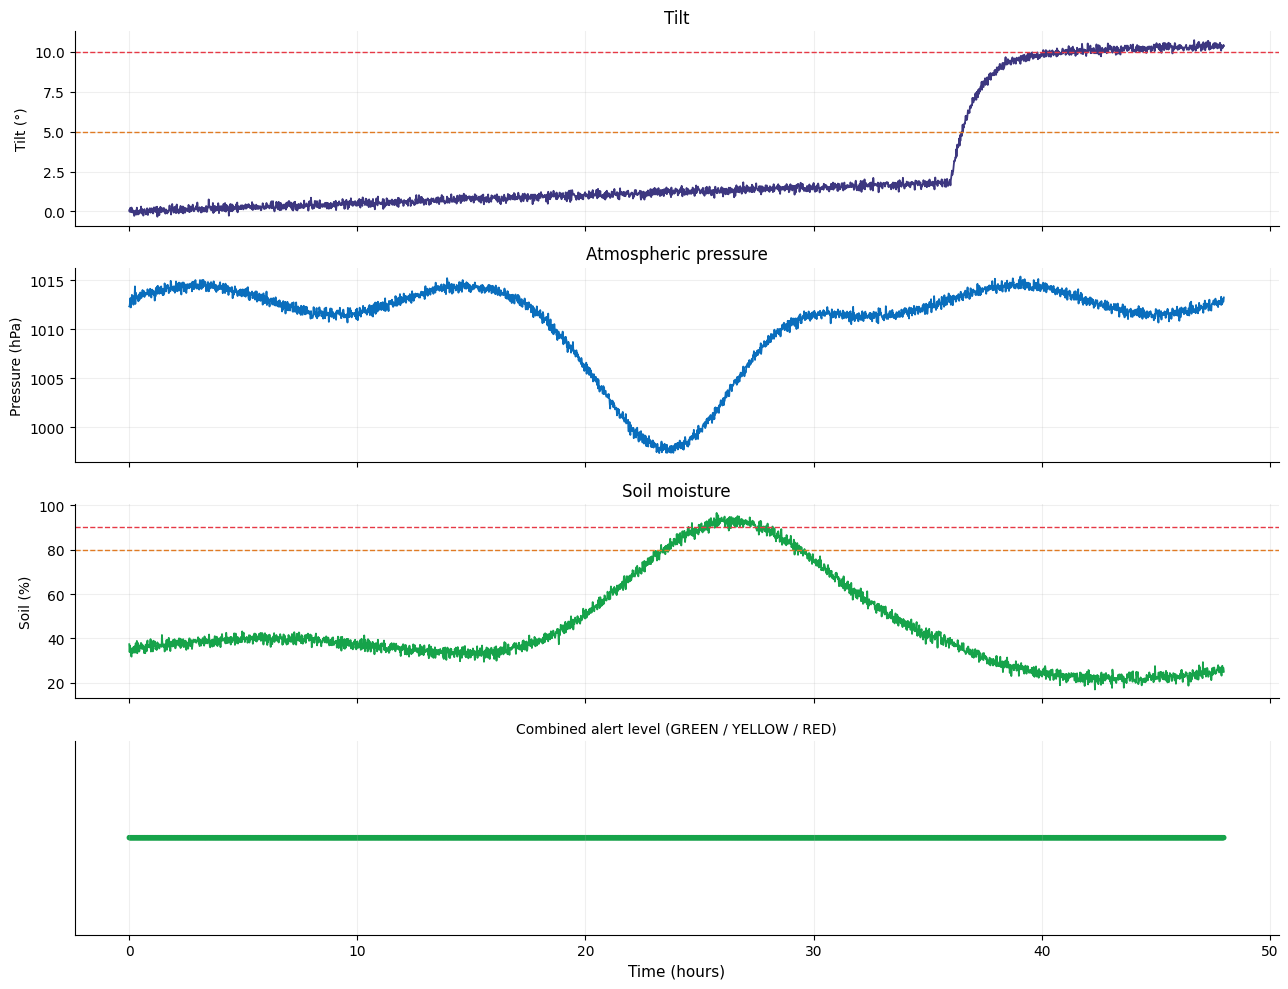

In [11]:
# Compute alert state for each timestamp
alert_state = np.full(n_samples, 'GREEN', dtype=object)
alert_state[(tilt_deg > 5) & (soil_pct > 80)]   = 'YELLOW'
alert_state[(tilt_deg > 10) & (soil_pct > 90)]  = 'RED'

# Find when each level was first hit
for level in ['YELLOW', 'RED']:
    idx = np.where(alert_state == level)[0]
    if len(idx) > 0:
        print(f'First {level} alert at hour {t_hours[idx[0]]:.1f}')
    else:
        print(f'{level} alert never triggered')

# Find storm alert
storm_idx = np.where(pressure_trend < -2)[0]
if len(storm_idx) > 0:
    print(f'\nFirst STORM alert at hour {t_hours[storm_idx[0]]:.1f}')
    print(f'(precedes first landslide alert by hours — useful lead time)')

# Combined plot
fig, axes = plt.subplots(4, 1, figsize=(13, 10), facecolor='white', sharex=True)

axes[0].plot(t_hours, tilt_deg, color=PURPLE, lw=1.3)
axes[0].axhline(5, color=ORANGE, ls='--', lw=1); axes[0].axhline(10, color=RED, ls='--', lw=1)
axes[0].set_ylabel('Tilt (°)', fontsize=10); axes[0].set_title('Tilt')

axes[1].plot(t_hours, pressure_hpa, color=BLUE, lw=1.3)
axes[1].set_ylabel('Pressure (hPa)', fontsize=10); axes[1].set_title('Atmospheric pressure')

axes[2].plot(t_hours, soil_pct, color=GREEN, lw=1.3)
axes[2].axhline(80, color=ORANGE, ls='--', lw=1); axes[2].axhline(90, color=RED, ls='--', lw=1)
axes[2].set_ylabel('Soil (%)', fontsize=10); axes[2].set_title('Soil moisture')

# Alert state colour bar
color_map = {'GREEN':'#16A34A', 'YELLOW':ORANGE, 'RED':RED}
colors = [color_map[s] for s in alert_state]
axes[3].scatter(t_hours, np.ones(n_samples), c=colors, s=8)
axes[3].set_yticks([])
axes[3].set_xlabel('Time (hours)', fontsize=11)
axes[3].set_title('Combined alert level (GREEN / YELLOW / RED)', fontsize=10)
axes[3].set_ylim(0, 2)

for ax in axes:
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## Part 5 — Publishing to MQTT (Same Protocol as Real ESP32)

Now we will **actually publish** sensor data to a public MQTT broker — exactly the same protocol your real ESP32 would use. The free broker `test.mosquitto.org` accepts any client, no authentication needed (do not use it in production).

**You can subscribe from another tool** (MQTT Explorer, mosquitto_sub, or another Python script) to confirm the messages arrive.

In [12]:
import paho.mqtt.publish as publish
import uuid

BROKER = 'test.mosquitto.org'
PORT   = 1883
CLIENT_ID = f'colab-{uuid.uuid4().hex[:8]}'
SITE   = f'demo_{CLIENT_ID}'   # use your name/team for the real workshop
TOPIC_PREFIX = f'digihaz/{SITE}'

print(f'Publishing as: {CLIENT_ID}')
print(f'Topic prefix:  {TOPIC_PREFIX}')
print(f'You can subscribe to:  {TOPIC_PREFIX}/#')
print()

# Build a JSON message — same format the ESP32 will use
def build_message(timestamp_h, tilt, pressure, soil_pct, alert):
    return {
        'ts':         datetime.now(timezone.utc).isoformat(),
        'site':       SITE,
        'tilt_deg':   round(float(tilt), 2),
        'press_hpa':  round(float(pressure), 2),
        'soil_pct':   round(float(soil_pct), 1),
        'alert':      alert,
        'sim_hour':   round(float(timestamp_h), 2),
    }

# Publish every 100th sample (to avoid flooding the public broker)
step = 100
samples_to_send = list(range(0, n_samples, step))
print(f'Sending {len(samples_to_send)} messages...')

for i in samples_to_send[:10]:  # demo: just the first 10 messages
    msg = build_message(t_hours[i], tilt_deg[i], pressure_hpa[i],
                        soil_pct[i], alert_state[i])
    payload = json.dumps(msg)
    try:
        publish.single(f'{TOPIC_PREFIX}/all', payload, hostname=BROKER, port=PORT,
                       qos=0, retain=False)
        print(f'  → t={t_hours[i]:5.1f}h  tilt={tilt_deg[i]:5.2f}°  soil={soil_pct[i]:5.1f}%  alert={alert_state[i]}')
        time.sleep(0.2)
    except Exception as e:
        print(f'  ✗ Publish failed: {e}')
        break

print(f'\n✅ Done. Subscribe to {TOPIC_PREFIX}/# from any MQTT client to see live messages.')

Publishing as: colab-c1079eb3
Topic prefix:  digihaz/demo_colab-c1079eb3
You can subscribe to:  digihaz/demo_colab-c1079eb3/#

Sending 29 messages...
  → t=  0.0h  tilt= 0.07°  soil= 37.4%  alert=GREEN
  → t=  1.7h  tilt=-0.13°  soil= 36.0%  alert=GREEN
  → t=  3.3h  tilt= 0.22°  soil= 37.8%  alert=GREEN
  → t=  5.0h  tilt= 0.13°  soil= 42.0%  alert=GREEN
  → t=  6.7h  tilt= 0.09°  soil= 40.3%  alert=GREEN
  → t=  8.3h  tilt= 0.56°  soil= 39.1%  alert=GREEN
  → t= 10.0h  tilt= 0.61°  soil= 38.7%  alert=GREEN
  → t= 11.7h  tilt= 0.50°  soil= 34.2%  alert=GREEN
  → t= 13.3h  tilt= 0.81°  soil= 31.3%  alert=GREEN
  → t= 15.0h  tilt= 0.81°  soil= 33.9%  alert=GREEN

✅ Done. Subscribe to digihaz/demo_colab-c1079eb3/# from any MQTT client to see live messages.


---
## 🧠 Reflection Questions

Answer in your Moodle journal:

1. The storm pressure alert fires **before** the soil saturation triggers a landslide alert. How could you use this lead time in a real-world EWS? How much warning does it give in this simulation?

2. The soil moisture is computed from a raw ADC value using the formula `100 * (ADC_DRY - raw) / (ADC_DRY - ADC_WET)`. What happens if the ADC reading is **higher** than `ADC_DRY` (drier than calibration)? Run a quick test — what value comes out? Is this acceptable?

3. We used a **public** MQTT broker (`test.mosquitto.org`) for this demo. List three reasons why this is not acceptable for a real EWS deployment and propose what should be used instead.

---
*DigiHaz Module 7 — Notebook 1 of 3 | github.com/Digihaz/digihaz-course-materials/tree/dev/module_07_iot_sensor_networks/topic_04*